<a href="https://colab.research.google.com/github/eldrey/topicos_contemporaneos/blob/main/Part%203-%20Agents/07%20-%20LangGraph%20Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Chat Básico

**Objetivo:** Receber uma mensagem do usuário e gerar uma resposta com LLM.

Esse é o caso mais básico de uso de LLM em LangGraph.

In [1]:
!pip install -U langchain-openai

In [2]:
import getpass
import os
# https://platform.openai.com/settings/organization/api-keys
os.environ["OPENAI_API_KEY"] = getpass.getpass()

··········


In [3]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages

In [4]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
from typing import Annotated, TypedDict

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [6]:
def chatbot(state: State):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

In [7]:
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

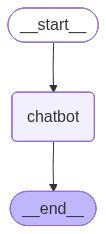

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="Qual é a capital de Pernambuco?"),
    ]
})

In [10]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Qual é a capital de Pernambuco?
================================== Ai Message ==================================

A capital de Pernambuco é Recife.


### Ferramentas

In [11]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Retorna a previsão do tempo para uma localização específica."""
    return f"A previsão do tempo em {location} é ensolarada com uma temperatura de 25°C."

tools = [get_weather]

In [12]:
llm_with_tools = llm.bind_tools(tools)

In [13]:
result = llm_with_tools.invoke("qual é a previsão do tempo em Natal?")
print(result)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 57, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c4585b5b9c', 'id': 'chatcmpl-CvqDsW6jLeq9Ipdsj4GQdmGc7Spmx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b9f23-b6b1-7411-8191-67595f38afe5-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Natal'}, 'id': 'call_n8NSZu0dMhylvkKYRTVcOzli', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 57, 'output_tokens': 14, 'total_tokens': 71, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [14]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [15]:
from langgraph.prebuilt import ToolNode, tools_condition

def chatbot(state: State):
    messages = state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}

tool_node = ToolNode(tools=tools)

In [16]:
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

builder.add_edge("tools", "chatbot")
builder.add_edge(START, "chatbot")

graph = builder.compile()

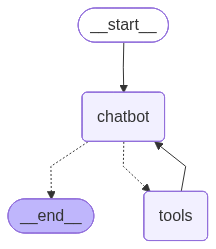

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [18]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="Qual é a previsão do tempo em Recife?"),
    ]
})

In [19]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Qual é a previsão do tempo em Recife?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_EZNetU5pLt7yFXvr83q2OAld)
 Call ID: call_EZNetU5pLt7yFXvr83q2OAld
  Args:
    location: Recife
================================= Tool Message =================================
Name: get_weather

A previsão do tempo em Recife é ensolarada com uma temperatura de 25°C.
================================== Ai Message ==================================

A previsão do tempo em Recife é ensolarada, com uma temperatura de 25°C.


## Exercícios

### Exercício 1
Crie um agente que escreva e leia arquivos de texto com o conteúdo solicitado pelo usuário.